In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src import (
    QlearningGreedy,
    ContextualLinUCB,
    SarsaGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

In [ ]:
bidder1 = QlearningGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)
bidder2 = QlearningGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)

simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

FPA_history_QQ = simulation.run()

Convergence detected after 79147 rounds.
Bidder Agent1 converged to 0.25
Bidder Agent2 converged to 0.25


In [ ]:
bidder1 = QlearningGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)
bidder2 = SarsaGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)

simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

FPA_history_QSarsa = simulation.run()

Convergence detected after 65539 rounds.
Bidder Agent1 converged to 0.2
Bidder Agent2 converged to 0.2


In [ ]:
bidder1 = ContextualLinUCB(name="LinUCB1", value=1, d=4, alpha=1, reg=1.0, n_bids=19)
bidder2 = SarsaGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)

simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

FPA_history_SarsaUCB = simulation.run()

In [5]:
bidder1 = QlearningGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)
bidder2 = ContextualLinUCB(name="LinUCB1", value=1, d=4, alpha=1, reg=1.0, n_bids=19)

simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

FPA_history_QUCB = simulation.run()

Convergence detected after 92514 rounds.
Bidder Agent1 converged to 0.5
Bidder LinUCB1 converged to 0.50


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

FPA_algorithms = pd.read_csv("Results_FPA/Algorithmic asymmetry/FPA_algorithmic_asymmetry.csv")

In [4]:
FPA_algorithms.head()

,pair_first,pair_second,simulation_id,rounds_to_convergence,converged_bid_Agent1,converged_bid_Agent2
0,QLearningGreedy,QLearningGreedy,0,84658,0.20,0.20
1,QLearningGreedy,QLearningGreedy,1,73393,0.15,0.15
2,QLearningGreedy,QLearningGreedy,2,77660,0.10,0.10
3,QLearningGreedy,QLearningGreedy,3,73973,0.20,0.20
4,QLearningGreedy,QLearningGreedy,4,61630,0.15,0.15


In [5]:
check_na = FPA_algorithms["converged_bid_Agent2"].dropna()
print(len(check_na))
print(len(FPA_algorithms))

600
600


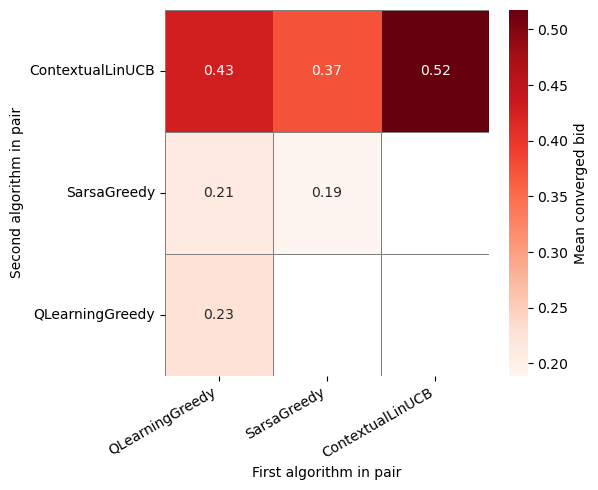

In [13]:
def plot_algorithm_grid(df, value_col="converged_bid_Agent1", save=False, title=None):
    # 1) Average across simulations
    agg = (
        df.groupby(["pair_first", "pair_second"])[value_col]
        .mean()
        .reset_index()
    )

    # 2) Pivot into grid
    pivot = agg.pivot(index="pair_second", columns="pair_first", values=value_col)

    # 3) Desired order
    desired_order = ["QLearningGreedy", "SarsaGreedy", "ContextualLinUCB"]
    pivot = pivot.reindex(columns=desired_order)
    # Reverse the order on the y-axis so it matches the x-axis orientation
    pivot = pivot.reindex(index=list(reversed(desired_order)))

    # 4) Plot
    plt.figure(figsize=(6,5))
    sns.heatmap(
        pivot,
        annot=True, fmt=".2f", cmap="Reds",
        cbar_kws={"label": "Mean converged bid"},
        linewidths=0.5, linecolor="gray"
    )
    plt.xlabel("First algorithm in pair")
    plt.ylabel("Second algorithm in pair")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save and title:
        plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")

    plt.show()


plot_algorithm_grid(FPA_algorithms, save=True, title="FPA_algorithm_grid")

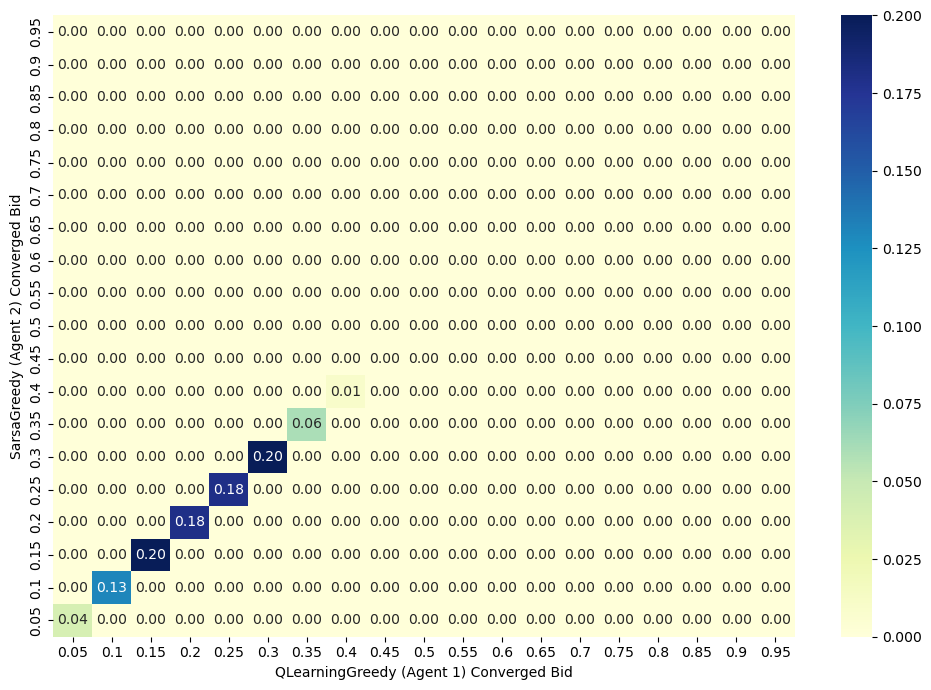

In [10]:
def plot_bid_heatmap(df, alg1, alg2, title=None):
    """
    Plot heatmap of converged bids between two algorithms.

    Parameters
    ----------
    df : DataFrame
        Must contain 'pair_first', 'pair_second',
        'converged_bid_Agent1', 'converged_bid_Agent2',
        and 'rounds_to_convergence'.
    alg1 : str
        Name of the algorithm assigned to Agent1 (pair_first).
    alg2 : str
        Name of the algorithm assigned to Agent2 (pair_second).
    title : str, optional
        Title for the plot / filename for saving.
    """
    # --- Filter rows to just the chosen pair ---
    subset = df[
        (df["pair_first"] == alg1) & (df["pair_second"] == alg2)
    ].dropna(subset=["rounds_to_convergence"])

    if subset.empty:
        print(f"No data found for pair ({alg1}, {alg2}).")
        return

    # --- Define bid grid ---
    bid_options = [round(i * 0.05, 2) for i in range(1, 20)]  # [0.05, ..., 0.95]

    # --- Build heatmap matrix ---
    heatmap_matrix = pd.DataFrame(0, index=bid_options, columns=bid_options, dtype=float)
    for b1, b2 in zip(subset["converged_bid_Agent1"], subset["converged_bid_Agent2"]):
        heatmap_matrix.at[round(b2, 2), round(b1, 2)] += 1  # Rows: Agent2, Cols: Agent1

    # Normalize to proportions
    heatmap_matrix /= heatmap_matrix.values.sum()

    # Flip y-axis so larger bids appear at top
    heatmap_matrix = heatmap_matrix.sort_index(ascending=False)

    # --- Plot ---
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        heatmap_matrix,
        cmap="YlGnBu",
        annot=True, fmt=".2f",
        xticklabels=bid_options, yticklabels=heatmap_matrix.index
    )
    plt.xlabel(f"{alg1} (Agent 1) Converged Bid")
    plt.ylabel(f"{alg2} (Agent 2) Converged Bid")
    plt.tight_layout()

    if title:
        plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")

    plt.show()

plot_bid_heatmap(FPA_algorithms, "QLearningGreedy", "SarsaGreedy", title="FPA_algorithm_asym_Q_Sarsa")

In [16]:
SPA_algorithms = pd.read_csv("Results_SPA/Algorithm asymmetry/SPA_algorithmic_asymmetry.csv")

SPA_algorithms.head()

,pair_first,pair_second,simulation_id,rounds_to_convergence,converged_bid_Agent1,converged_bid_Agent2
0,QLearningGreedy,QLearningGreedy,0,250872.0,0.95,0.95
1,QLearningGreedy,QLearningGreedy,1,222766.0,0.95,0.95
2,QLearningGreedy,QLearningGreedy,2,280976.0,0.95,0.95
3,QLearningGreedy,QLearningGreedy,3,235016.0,0.95,0.95
4,QLearningGreedy,QLearningGreedy,4,235254.0,0.95,0.95


In [18]:
SPA_algorithms = SPA_algorithms[
    ~(
        (SPA_algorithms["pair_first"] == "ContextualLinUCB") &
        (SPA_algorithms["pair_second"] == "ContextualLinUCB") &
        (SPA_algorithms["simulation_id"] == 14)
    )
]

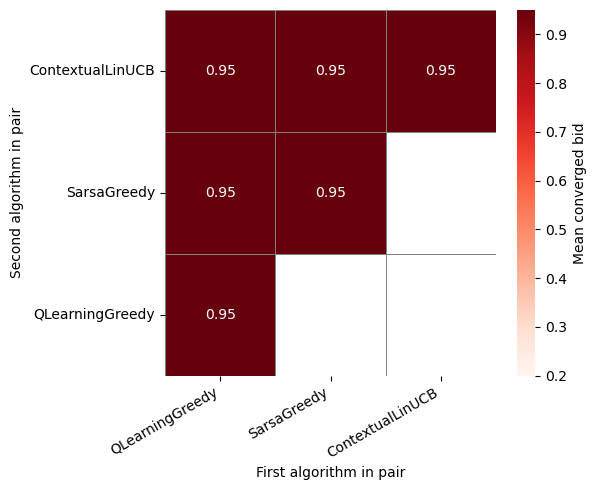

In [23]:
def SPA_plot_algorithm_grid(df, value_col="converged_bid_Agent1", save=False, title=None):
    # 1) Average across simulations
    agg = (
        df.groupby(["pair_first", "pair_second"])[value_col]
        .mean()
        .reset_index()
    )

    # 2) Pivot into grid
    pivot = agg.pivot(index="pair_second", columns="pair_first", values=value_col)

    # 3) Desired order
    desired_order = ["QLearningGreedy", "SarsaGreedy", "ContextualLinUCB"]
    pivot = pivot.reindex(columns=desired_order)
    # Reverse the order on the y-axis so it matches the x-axis orientation
    pivot = pivot.reindex(index=list(reversed(desired_order)))

    #Control colour gradient so that it is not too strong
    # 🔑 4) Control colormap normalization
    vmin = 0.2   # Lower bound of the color scale
    vmax = 0.95   # Upper bound of the color scale

    # 4) Plot
    plt.figure(figsize=(6,5))
    sns.heatmap(
        pivot,
        annot=True, fmt=".2f", cmap="Reds",
        cbar_kws={"label": "Mean converged bid"},
        linewidths=0.5, linecolor="gray",
        vmin=vmin, vmax=vmax
    )
    plt.xlabel("First algorithm in pair")
    plt.ylabel("Second algorithm in pair")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save and title:
        plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")

    plt.show()


SPA_plot_algorithm_grid(SPA_algorithms, save=True, title="SPA_algorithm_matrix")